<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%205/W05_L3_Finetuning_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=A8MjQoeiSgo) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%205/NPTEL_Jul24_DL4CV_W05_P03.pdf)

In [ ]:
# Week 5, Lecture 3: Finetuning CNN
from IPython.display import HTML, display

VIDEO_ID = "A8MjQoeiSgo"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# Week 5, Lecture 3: Finetuning CNNs (Transfer Learning)

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§5.3 Finetuning in CNNs**.

Training a deep CNN from scratch needs lots of data, compute, and careful tuning. This lecture shows how to instead **reuse** a network pretrained on a large dataset (ImageNet) and adapt it to a new task with very little data. This is **transfer learning**, the workhorse of practical computer vision.

**What you will learn**
- Understand why training CNNs from scratch is hard: optimization, overfitting, and compute cost.
- See that CNN features are **hierarchical**: early layers are generic (edges, colors), later layers are specialized.
- Understand **transfer learning** and its two modes: **feature extraction** vs **fine-tuning**.
- Freeze and unfreeze layers in PyTorch and count trainable parameters.
- Run a hands-on transfer-learning micro-demo on a tiny dataset and beat a from-scratch baseline.
- Choose the right strategy based on **dataset size** and **domain similarity**.

**How to run**

- **Self-contained:** every import and download happens inside the notebook.
- **Runs on CPU or GPU**, locally or on **Google Colab**. All cells are kept tiny and fast.
- **Interactive:** several cells build a widget. Run the cell, then drag the slider or pick from the dropdown and watch the output update.
- **Reproducible:** seeds are set in the setup cell below.

In [1]:
# Setup: runs on CPU or GPU, on Colab or locally.
import sys, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ipywidgets is preinstalled on Colab; install only if missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, interactive
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, interactive

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

def count_params(module):
    """Total number of parameters in a module."""
    return sum(p.numel() for p in module.parameters())

def count_trainable(module):
    """Number of parameters that will receive gradients."""
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

Using device: cpu


## 1. Why finetune? Training from scratch is hard

Training a deep CNN from random initialization is expensive on three axes:

- **Optimization is delicate.** Deep nets need careful weight initialization, normalization, and learning-rate schedules to converge at all.
- **Overfitting on small data.** A network with tens of millions of parameters memorizes a small dataset instead of generalizing.
- **Compute is heavy.** The classic ImageNet models took days to weeks on multiple GPUs to train.

**Parameter counts and original training cost** (approximate):

| Model | Parameters | Original training time |
|---|---|---|
| AlexNet | ~60M | 5 to 6 days |
| VGG-16 | ~138M | 2 to 3 weeks |
| Inception-v1 (GoogLeNet) | ~5M | ~1 week |
| ResNet-50 | ~25M | (days on multiple GPUs) |

**Takeaway:** if someone already paid this cost on ImageNet, we should **reuse** their trained weights rather than start over.

In [2]:
# Sanity check: count parameters of standard torchvision models (structure only, no weights).
import torchvision.models as models

specs = [
    ("AlexNet",      models.alexnet(weights=None),      "5 to 6 days"),
    ("VGG-16",       models.vgg16(weights=None),        "2 to 3 weeks"),
    ("Inception-v1", models.googlenet(weights=None, init_weights=False), "~1 week"),
    ("ResNet-50",    models.resnet50(weights=None),     "days, multi-GPU"),
]

print(f"{'Model':<14}{'Params (M)':>12}   {'Train time':<16}")
print("-" * 46)
for name, m, t in specs:
    p = count_params(m) / 1e6
    print(f"{name:<14}{p:>12.1f}   {t:<16}")
print("\nHuge param counts + long training = strong reason to reuse pretrained weights.")

Model           Params (M)   Train time      
----------------------------------------------
AlexNet               61.1   5 to 6 days     
VGG-16               138.4   2 to 3 weeks    
Inception-v1          13.0   ~1 week         
ResNet-50             25.6   days, multi-GPU 

Huge param counts + long training = strong reason to reuse pretrained weights.


## 2. Hierarchical features: generic early, specialized late

A CNN learns a **hierarchy** of features:

- **Early layers** learn **generic** patterns: oriented **edges**, **color blobs**, and **Gabor-like** textures. These look almost the same no matter what the network was trained on, so they **transfer** well across tasks.
- **Later layers** learn **specialized** features: object parts and whole-object detectors that are tuned to the **specific** training dataset.

This is the key insight behind transfer learning: keep the reusable early layers, and only relearn the task-specific later part.

Below we load a **pretrained resnet18** and visualize its very first convolution layer, which has shape `[64, 3, 7, 7]` (64 filters, each a 3-channel 7x7 RGB patch).

Loaded pretrained resnet18.
conv1 weight shape: (64, 3, 7, 7)


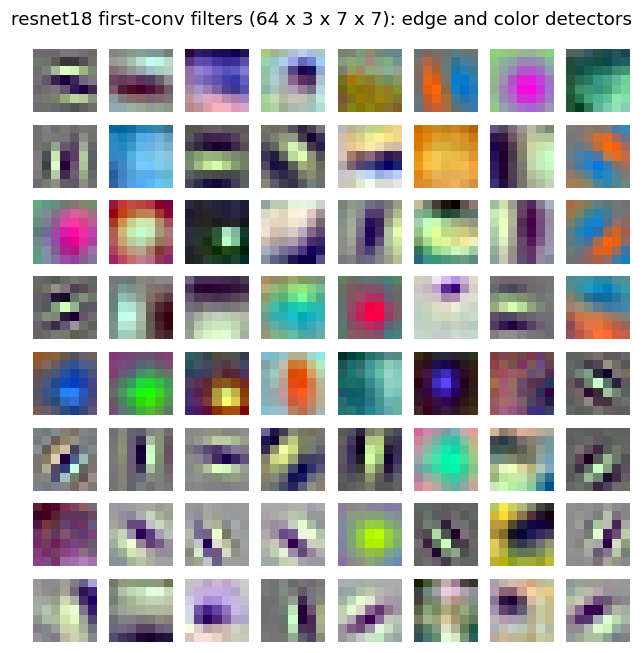

In [3]:
from torchvision.models import resnet18, ResNet18_Weights

# Load resnet18 with ImageNet-pretrained weights (cached after first download).
weights = ResNet18_Weights.DEFAULT
net = resnet18(weights=weights).to(device).eval()
print("Loaded pretrained resnet18.")

# First conv layer filters: shape [64, 3, 7, 7].
W = net.conv1.weight.data.clone().cpu()
print("conv1 weight shape:", tuple(W.shape))

# Normalize EACH filter independently to [0, 1] so we can view it as an RGB image.
def to_rgb(f):
    f = f - f.min()
    f = f / (f.max() + 1e-8)
    return f.permute(1, 2, 0).numpy()   # C,H,W -> H,W,C

fig, axes = plt.subplots(8, 8, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(to_rgb(W[i]))
    ax.axis('off')
fig.suptitle('resnet18 first-conv filters (64 x 3 x 7 x 7): edge and color detectors', y=0.93)
plt.show()

**What to notice:** many filters look like **oriented edge detectors** (light-dark stripes at various angles) and others are smooth **color blobs** (opponent red/green, blue/yellow). These are generic, task-agnostic features. Almost every natural-image task benefits from them, which is exactly why they transfer.

## 3. The transfer learning idea

**Transfer learning:** take knowledge learned on a large **source** task (ImageNet, ~1.2M images, 1000 classes) and reuse it to help a **target** task that has little labeled data.

A pretrained CNN splits naturally into two parts:

$$\underbrace{\text{conv layers}}_{\text{feature extractor (backbone)}} \;\to\; \underbrace{\text{fully-connected}}_{\text{classifier head}}$$

Two modes of transfer:

- **(a) Feature extraction:** **freeze** the backbone and train only a **new head**. The backbone acts as a fixed function that turns an image into a feature vector. Fast, few parameters, resists overfitting.
- **(b) Fine-tuning:** use the pretrained weights as an **initialization** and keep training some or all layers, usually with a **low learning rate** so we do not destroy the learned features.

**Which to choose** depends on how big the target dataset is and how **similar** it is to the source. We build a decision guide in Section 6.

## 4. Freezing layers in PyTorch

Two mechanics do all the work:

- **Freeze a parameter:** set `param.requires_grad = False`. Frozen params receive no gradient and never update.
- **Replace the head:** swap `net.fc` (a `Linear(512, 1000)` for ImageNet) with a fresh `Linear(512, K)` for your `K` classes. A newly created layer has `requires_grad=True` by default, so only the head trains.

resnet18's body is organized into stages `layer1, layer2, layer3, layer4` (increasingly specialized), followed by `fc`. **Unfreezing** more of the late stages moves you along a spectrum from **pure feature extraction** (only `fc` trains) to **full fine-tuning** (everything trains).

In [4]:
from torchvision.models import resnet18, ResNet18_Weights

K = 4  # number of target classes for our demo

def make_transfer_model(num_classes=K):
    m = resnet18(weights=ResNet18_Weights.DEFAULT)
    for p in m.parameters():          # freeze the whole backbone
        p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, num_classes)  # fresh trainable head
    return m

model = make_transfer_model(K)
tot = count_params(model)
tr  = count_trainable(model)
print(f"Total parameters:     {tot:,}")
print(f"Trainable parameters: {tr:,}  ({100*tr/tot:.3f}% of total)")
print(f"\nOnly the new fc head ({model.fc.in_features} -> {K}) trains; "
      f"the {tot-tr:,} backbone params are frozen.")

Total parameters:     11,178,564
Trainable parameters: 2,052  (0.018% of total)

Only the new fc head (512 -> 4) trains; the 11,176,512 backbone params are frozen.


### Widget: unfreeze the last N stages

**Try this:** move from *none* (pure feature extraction) toward *all* (full fine-tuning) and watch the trainable parameter count and its share of the total grow.

In [5]:
from torchvision.models import resnet18, ResNet18_Weights

# Build once; the widget just toggles requires_grad flags (instant).
_base = resnet18(weights=ResNet18_Weights.DEFAULT)
_base.fc = nn.Linear(_base.fc.in_features, K)
_TOTAL = count_params(_base)

# Ordered from head outward. Each option unfreezes fc plus the listed stages.
UNFREEZE = {
    'none (fc only)':      ['fc'],
    'layer4':              ['fc', 'layer4'],
    'layer3 + layer4':     ['fc', 'layer4', 'layer3'],
    'all (full finetune)': ['fc', 'layer4', 'layer3', 'layer2', 'layer1', 'conv1', 'bn1'],
}

def _unfreeze_demo(scope='none (fc only)'):
    stages = UNFREEZE[scope]
    for name, p in _base.named_parameters():
        p.requires_grad = any(name.startswith(s) for s in stages)
    tr = count_trainable(_base)
    pct = 100 * tr / _TOTAL

    fig, ax = plt.subplots(figsize=(6, 2.6))
    ax.barh([0], [pct], color='#4C72B0')
    ax.set_xlim(0, 100)
    ax.set_yticks([])
    ax.set_xlabel('% of parameters trainable')
    ax.set_title(f"Unfreeze: {scope}\n{tr:,} / {_TOTAL:,} trainable  ({pct:.2f}%)")
    plt.show()

interact(_unfreeze_demo,
         scope=widgets.Dropdown(options=list(UNFREEZE.keys()),
                                value='none (fc only)', description='unfreeze'));

interactive(children=(Dropdown(description='unfreeze', options=('none (fc only)', 'layer4', 'layer3 + layer4',…

**What to notice:** `fc` alone is a tiny fraction of the parameters. `layer4` holds most of resnet18's weights (the widest, most specialized stage), so unfreezing it jumps the trainable share sharply. This is the **feature-extraction to fine-tuning spectrum** in one control.

## 5. Hands-on micro-demo: feature extraction on a tiny CIFAR-10 subset

Plan:

1. Use the **frozen** resnet18 up to its global average pool as a **fixed feature extractor** (output is a 512-dim vector per image).
2. Extract features **once** under `torch.no_grad()` and **cache** them. This is the expensive step, and we only pay it a single time.
3. Train a lightweight **linear classifier** on top of the cached features for a few epochs. This is tiny and fast.
4. Compare against a small CNN trained **from scratch** on the same tiny data.

We use a small subset of CIFAR-10: a few classes, about 120 to 150 train and 40 to 50 test images per class, resized to 96x96 and normalized with ImageNet statistics.

In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

CLASSES = [0, 1, 8, 9]          # airplane, automobile, ship, truck (vehicles: a coherent 4-class task)
CLASS_NAMES = ['airplane', 'automobile', 'ship', 'truck']
N_TRAIN_PER = 150               # images per class for training
N_TEST_PER  = 50                # images per class for testing
IMG = 96

imagenet_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                      std=[0.229, 0.224, 0.225])
tf = transforms.Compose([
    transforms.Resize(IMG),
    transforms.ToTensor(),
    imagenet_norm,
])

train_full = datasets.CIFAR10(root='./data', train=True,  download=True, transform=tf)
test_full  = datasets.CIFAR10(root='./data', train=False, download=True, transform=tf)

remap = {c: i for i, c in enumerate(CLASSES)}   # original label -> 0..K-1

def subset_indices(ds, per_class):
    targets = np.array(ds.targets)
    idx = []
    for c in CLASSES:
        cand = np.where(targets == c)[0][:per_class]
        idx.extend(cand.tolist())
    return idx

train_idx = subset_indices(train_full, N_TRAIN_PER)
test_idx  = subset_indices(test_full,  N_TEST_PER)
train_sub = Subset(train_full, train_idx)
test_sub  = Subset(test_full,  test_idx)
print(f"Classes: {CLASS_NAMES}")
print(f"Train images: {len(train_sub)}   Test images: {len(test_sub)}   (size {IMG}x{IMG})")

Classes: ['airplane', 'automobile', 'ship', 'truck']
Train images: 600   Test images: 200   (size 96x96)


In [7]:
from torchvision.models import resnet18, ResNet18_Weights

# Feature extractor = pretrained resnet18 with its fc removed (identity), frozen and in eval mode.
backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
backbone.fc = nn.Identity()          # output is the 512-dim pooled feature
backbone = backbone.to(device).eval()
for p in backbone.parameters():
    p.requires_grad = False

@torch.no_grad()
def extract_features(subset):
    loader = DataLoader(subset, batch_size=64, shuffle=False)
    feats, labels = [], []
    for xb, yb in loader:
        f = backbone(xb.to(device)).cpu()
        feats.append(f)
        labels.append(torch.tensor([remap[int(y)] for y in yb]))
    return torch.cat(feats), torch.cat(labels)

t0 = time.time()
Xtr, ytr = extract_features(train_sub)   # cache: computed ONCE
Xte, yte = extract_features(test_sub)
print(f"Extracted features in {time.time()-t0:.1f}s")
print("Train feature matrix:", tuple(Xtr.shape), " Test:", tuple(Xte.shape))

Extracted features in 2.5s
Train feature matrix: (600, 512)  Test: (200, 512)


In [8]:
# Train a single Linear head on the cached 512-dim features. This is fast because
# no convolutions run during training: we already cached the features.
def train_linear_head(Xtr, ytr, Xte, yte, num_classes, epochs=40, lr=0.05, seed=0):
    torch.manual_seed(seed)
    head = nn.Linear(Xtr.shape[1], num_classes)
    opt = torch.optim.SGD(head.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    lossf = nn.CrossEntropyLoss()
    for ep in range(epochs):
        head.train()
        opt.zero_grad()
        loss = lossf(head(Xtr), ytr)
        loss.backward()
        opt.step()
    head.eval()
    with torch.no_grad():
        acc = (head(Xte).argmax(1) == yte).float().mean().item()
    return acc, head

t0 = time.time()
feat_acc, _ = train_linear_head(Xtr, ytr, Xte, yte, len(CLASSES))
print(f"Frozen features + linear head test accuracy: {feat_acc*100:.1f}%  "
      f"(trained in {time.time()-t0:.2f}s)")

Frozen features + linear head test accuracy: 87.0%  (trained in 0.03s)


In [9]:
# Baseline: a tiny CNN trained FROM SCRATCH on the same tiny data, comparable budget.
class TinyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 96 -> 48
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 48 -> 24
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Linear(64, num_classes)
    def forward(self, x):
        z = self.features(x).flatten(1)
        return self.head(z)

def train_from_scratch(train_sub, test_sub, num_classes, epochs=12, lr=0.01, seed=0):
    torch.manual_seed(seed)
    net = TinyCNN(num_classes).to(device)
    opt = torch.optim.SGD(net.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    lossf = nn.CrossEntropyLoss()
    tr_loader = DataLoader(train_sub, batch_size=64, shuffle=True)
    for ep in range(epochs):
        net.train()
        for xb, yb in tr_loader:
            yb = torch.tensor([remap[int(y)] for y in yb]).to(device)
            opt.zero_grad()
            loss = lossf(net(xb.to(device)), yb)
            loss.backward(); opt.step()
    net.eval()
    correct = tot = 0
    te_loader = DataLoader(test_sub, batch_size=64)
    with torch.no_grad():
        for xb, yb in te_loader:
            yb = torch.tensor([remap[int(y)] for y in yb]).to(device)
            pred = net(xb.to(device)).argmax(1)
            correct += (pred == yb).sum().item(); tot += len(yb)
    return correct / tot

t0 = time.time()
scratch_acc = train_from_scratch(train_sub, test_sub, len(CLASSES))
print(f"Tiny CNN from scratch test accuracy: {scratch_acc*100:.1f}%  "
      f"(trained in {time.time()-t0:.1f}s)")

Tiny CNN from scratch test accuracy: 40.0%  (trained in 9.4s)


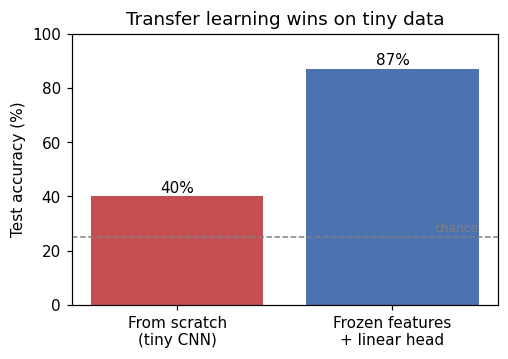

In [10]:
# Compare: from scratch vs frozen features + linear head.
fig, ax = plt.subplots(figsize=(5, 3.2))
names = ['From scratch\n(tiny CNN)', 'Frozen features\n+ linear head']
vals = [scratch_acc*100, feat_acc*100]
bars = ax.bar(names, vals, color=['#C44E52', '#4C72B0'])
ax.set_ylabel('Test accuracy (%)')
ax.set_ylim(0, 100)
ax.axhline(100/len(CLASSES), ls='--', color='gray', lw=1)
ax.text(1.4, 100/len(CLASSES)+2, 'chance', color='gray', ha='right', fontsize=8)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+1.5, f'{v:.0f}%', ha='center')
ax.set_title('Transfer learning wins on tiny data')
plt.show()

**What to notice:** with only a few hundred images, the **from-scratch** CNN struggles (little data, random init), while **frozen pretrained features + a linear head** reaches much higher accuracy in a fraction of the time. The pretrained backbone already knows how to see; we only teach it a new decision rule.

### Widget: data-efficiency curve

We already cached the full feature matrix, so this widget just **subsamples** the cached features and **retrains the fast linear head**. No convolutions rerun, so it is instant.

**Try this:** drop to just a handful of images per class and see that transfer still works far above chance. This is the practical payoff: **transfer learning is data-efficient**.

In [11]:
# Precompute a per-class index list into the cached training features for fast subsampling.
_by_class = {c: (ytr == c).nonzero(as_tuple=True)[0] for c in range(len(CLASSES))}

def _data_efficiency(n_per_class=150):
    g = torch.Generator().manual_seed(0)
    sel = []
    for c in range(len(CLASSES)):
        pool = _by_class[c]
        k = min(n_per_class, len(pool))
        perm = torch.randperm(len(pool), generator=g)[:k]
        sel.append(pool[perm])
    sel = torch.cat(sel)
    acc, _ = train_linear_head(Xtr[sel], ytr[sel], Xte, yte, len(CLASSES))

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar([0], [acc*100], color='#4C72B0', width=0.5)
    ax.set_xlim(-1, 1); ax.set_ylim(0, 100); ax.set_xticks([])
    ax.axhline(100/len(CLASSES), ls='--', color='gray', lw=1)
    ax.set_ylabel('Test accuracy (%)')
    ax.set_title(f'{n_per_class} imgs/class  ->  {acc*100:.1f}% test acc')
    plt.show()

interact(_data_efficiency,
         n_per_class=widgets.IntSlider(min=5, max=N_TRAIN_PER, step=5,
                                       value=N_TRAIN_PER, description='imgs/class'));

interactive(children=(IntSlider(value=150, description='imgs/class', max=150, min=5, step=5), Output()), _dom_…

## 6. Decision guide: which strategy to use

The practical heart of the lecture is a **2x2 matrix** over **dataset size** (small vs large) and **domain similarity** to ImageNet (similar vs dissimilar):

| | **Similar domain** | **Dissimilar domain** |
|---|---|---|
| **Small data** | Freeze the backbone, train only a **linear classifier** (prevents overfitting). | Take features from an **earlier layer** (more generic) and train a simple classifier (linear or SVM). |
| **Large data** | **Fine-tune** the whole network, using pretrained weights as a strong initialization. | **Fine-tune** the whole network; if very different, consider training **from scratch**. |

Intuition:
- **Little data** means few trainable parameters, so favor **freezing** to avoid overfitting.
- **Dissimilar domain** means the specialized late features do not transfer, so rely on the **generic early** features.
- **Lots of data** means you can afford to update many parameters, so **fine-tune** broadly.

### Widget: pick your situation, get a recommendation

**Try this:** set the two dropdowns to your real-world scenario and read off the recommended strategy.

In [12]:
RECS = {
    ('small', 'similar'): (
        "Freeze the backbone; train ONLY a linear classifier head.",
        "Few labels + similar features: freezing avoids overfitting and reuses the pretrained features directly."),
    ('small', 'dissimilar'): (
        "Use features from an EARLIER layer; train a simple classifier (linear or SVM).",
        "Late features are ImageNet-specific and will not transfer; early features are generic and still useful."),
    ('large', 'similar'): (
        "Fine-tune the WHOLE network with a low learning rate.",
        "Enough data to update all layers safely; pretrained weights give a strong initialization."),
    ('large', 'dissimilar'): (
        "Fine-tune the whole network; if the domain is very different, consider training from scratch.",
        "Plenty of data can adapt even specialized layers; a very different domain may need fresh features."),
}

def _decide(dataset_size='small', similarity='similar'):
    strategy, reason = RECS[(dataset_size, similarity)]
    print(f"Situation : {dataset_size} data, {similarity} domain")
    print("-" * 60)
    print("Strategy  :", strategy)
    print("Why       :", reason)

interact(_decide,
         dataset_size=widgets.Dropdown(options=['small', 'large'], value='small',
                                       description='data size'),
         similarity=widgets.Dropdown(options=['similar', 'dissimilar'], value='similar',
                                     description='similarity'));

interactive(children=(Dropdown(description='data size', options=('small', 'large'), value='small'), Dropdown(d…

## 7. Fine-tuning tips

When you do choose to fine-tune (not just feature-extract):

- **Use a low learning rate.** A large step would wash out the carefully learned pretrained features before they can help.
- **Discriminative learning rates.** Give **early layers a smaller LR** (they are generic, change them little) and the **head a larger LR** (it is new and must learn fast). Implement this with **parameter groups**.
- **Data augmentation.** Random crops, flips, and color jitter enlarge a small dataset and reduce overfitting during fine-tuning.

Below is the standard pattern: build one optimizer with **two param groups**, a small LR for the backbone and a larger LR for the head.

In [13]:
from torchvision.models import resnet18, ResNet18_Weights

ft = resnet18(weights=ResNet18_Weights.DEFAULT)
ft.fc = nn.Linear(ft.fc.in_features, K)   # fresh head for K classes

backbone_params = [p for n, p in ft.named_parameters() if not n.startswith('fc')]
head_params     = [p for n, p in ft.named_parameters() if n.startswith('fc')]

optimizer = torch.optim.SGD([
    {'params': backbone_params, 'lr': 1e-4},   # small LR: preserve pretrained features
    {'params': head_params,     'lr': 1e-2},   # larger LR: learn the new head fast
], momentum=0.9, weight_decay=1e-4)

# Example augmentation pipeline you would use for the training data.
aug = transforms.Compose([
    transforms.RandomResizedCrop(IMG, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    imagenet_norm,
])

for i, grp in enumerate(optimizer.param_groups):
    n = sum(p.numel() for p in grp['params'])
    print(f"param group {i}: lr={grp['lr']:<7} params={n:,}")
print("\nBackbone updates slowly, head updates quickly: discriminative learning rates.")

param group 0: lr=0.0001  params=11,176,512
param group 1: lr=0.01    params=2,052

Backbone updates slowly, head updates quickly: discriminative learning rates.


## 8. Key takeaways

- Training deep CNNs from scratch is **hard**: fragile optimization, easy overfitting on small data, and large compute cost.
- CNN features are **hierarchical**: early layers are **generic** (edges, colors) and transfer widely; late layers are **specialized** to the source task.
- **Transfer learning** reuses a network pretrained on a large source (ImageNet) for a small target task.
- Two modes: **feature extraction** (freeze backbone, train a new head) and **fine-tuning** (keep training with a low LR). In PyTorch, control this with `requires_grad` and by replacing `fc`.
- On tiny data, **frozen features + a linear head** beat a from-scratch CNN, and stay strong even with very few labels.
- Pick your strategy from the **size x similarity** matrix: small data favors freezing; dissimilar domains favor earlier (more generic) features; large data allows full fine-tuning.

## Further reading

- Yosinski, Clune, Bengio, Lipson, **"How transferable are features in deep neural networks?"** NeurIPS 2014.
- Goodfellow, Bengio, Courville, **Deep Learning**, Chapter 9.8 to 9.9 (convolutional networks and their variants).
- Stanford **CS231n**, transfer learning notes: https://cs231n.github.io/transfer-learning/